In [2]:
import numpy as np
import pandas as pd
import string
import numpy as np
import regex as re
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('../Data/WELFake_Dataset.csv',index_col=None)
print(data.info())
data = data.fillna('')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB
None


In [6]:
def preprocess_data(data):
  ''' removing punctuations, deleting alphanumeric characters, converting uppercase characters to lowercase. '''

  data['title_text'] = data['title'] +' '+ data['text']

  data['title_text'] = data['title_text'].astype(str).str.lower()
  data['title_text'] = data['title_text'].str.replace(r'http\S+|www\S+', '', regex=True)

  data['title_text'] = data['title_text'].str.replace(r'#\w+', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'@\w+', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'\S*\*\S*', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'\n', ' ', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'[\n\r\t]', ' ', regex=True)

  data['title_text'] = data['title_text'].apply(lambda x: re.sub(r'\p{P}+', '', x))
  data['title_text'] = data['title_text'].apply(lambda x: re.sub(r'[\x00-\x1f\x7f-\x9f]', '', x))
  data['title_text'] = data['title_text'].str.replace(r'\w*\d\w*', '', regex=True)
  data['title_text'] = data['title_text'].apply(lambda x: re.sub(' +',' ',x))
  return data

tmp_data = data.copy()
preprocessed_data = preprocess_data(tmp_data)

In [7]:
preprocessed_data = preprocessed_data[['title','text','title_text','label']]
preprocessed_data.head()

,title,text,title_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,law enforcement on high alert following threat...,1
1,,Did they post their votes for Hillary already?,did they post their votes for hillary already,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",unbelievable obamas attorney general says most...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,bobby jindal raised hindu uses story of christ...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",satan russia unvelis an image of its terrifyin...,1


In [8]:
preprocessed_data.to_csv('../Data/preprocessed_data.csv',index=False)

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [10]:
fake_titles = ' '.join(preprocessed_data[preprocessed_data['label'] == 0]['text'])
real_titles = ' '.join(preprocessed_data[preprocessed_data['label'] == 1]['text'])
fake_wordcloud = WordCloud(
    background_color='black',
    max_words=300,
    width=800,
    height=400,
).generate(fake_titles)
real_wordcloud = WordCloud(
    background_color='black',
    max_words=300,
    width=800,
    height=400,
).generate(real_titles)

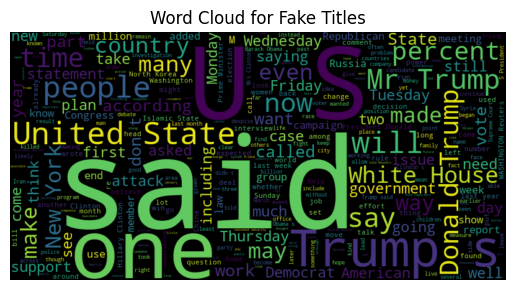

In [11]:
# plt.figure(figsize=(20, 10))
plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Fake Titles')
plt.axis("off")
plt.show()

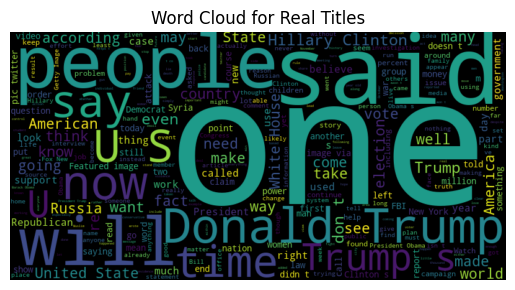

In [12]:
# plt.figure(figsize=(20, 10))
plt.imshow(real_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Real Titles')
plt.axis("off")
plt.show()

In [3]:
preprocessed_data = pd.read_csv('../Data/preprocessed_data.csv',index_col=None)

In [4]:
def tokenize(data):
  if isinstance(data['title_text'][0],list):
    return data
  data['title_text'] = data['title_text'].str.strip()
  data['title_text'] = data['title_text'].apply(lambda x: x.split(' '))
  return data

preprocessed_data = tokenize(preprocessed_data).fillna('')

In [5]:
len(preprocessed_data)

72134

In [6]:
preprocessed_data1=preprocessed_data.iloc[:10000]

In [7]:
def vocabulary(data):
    vocab=dict()
    idx=0
    while idx<10000:
        for w in data.iloc[idx]['title_text']:
            if w not in vocab:
                vocab[w]=1
            else:
                vocab[w]+=1
        idx+=1
    sorted_vocab = dict(sorted(vocab.items(), key=lambda item: item[1], reverse=True))
    NUM=20000
    i=0
    sorted_vocab_20=dict()
    for key,value in sorted_vocab.items():
        if i<NUM:
            sorted_vocab_20[key]=value
            i+=1
        else:
            break
    return sorted_vocab_20

In [8]:
vocab_20=vocabulary(preprocessed_data1)

In [9]:
'''splitting the data into test and train '''
train_data, test_data = train_test_split(preprocessed_data1, test_size=0.2, random_state=42)

In [67]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       8000 non-null   object
 1   text        8000 non-null   object
 2   title_text  8000 non-null   object
 3   label       8000 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 312.5+ KB


In [68]:
train_data.iloc[0]

title         Refusing to sit on Lead, Trump Gets Bitter in ...
text          The New York billionaire went into the CBS deb...
title_text    [refusing, to, sit, on, lead, trump, gets, bit...
label                                                         0
Name: 9254, dtype: object

In [69]:
from gensim.models import Word2Vec
import numpy as np

In [ ]:
news_contents = preprocessed_data['title_text'].copy()
news_contents = news_contents.to_list()
model1 = Word2Vec(news_contents,vector_size=100,window=5,min_count=5,sg=0)

In [71]:
len(news_contents)

72134

In [ ]:
def to_word2vec_cbow(m,news_contents,vocab):
  print("hi")
  news_vectors=[]
  for news in news_contents:
    news_vectors1=[]
    cnt=0
    for w in news:
      if w in vocab.keys() and cnt<1000:
        news_vectors1.append(m.wv[w])
        cnt+=1
    for i in range(1000-cnt):
        news_vectors1.append(np.zeros((100,)))
    news_vectors.append(news_vectors1)
  news_vectors = np.array(news_vectors)
  return news_vectors
news_vectors = to_word2vec_cbow(model1,train_data['title_text'].copy(),vocab_20)

hi


In [73]:
news_vectors = np.array(news_vectors)
news_vectors[0]

array([[ 0.64289731, -0.41305587, -0.35041049, ..., -0.71109986,
        -2.73428726,  2.79166079],
       [-0.56760532,  0.49328679, -1.1801877 , ..., -0.59581614,
        -2.10210967, -0.62372595],
       [ 2.66778731,  1.31921208, -1.11182904, ..., -0.29426762,
        -1.44126749,  0.37619066],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
news_vectors_test = to_word2vec_cbow(model1,test_data['title_text'].to_list(),vocab_20)
news_vectors_test = np.array(news_vectors_test)

hi


In [76]:
np.save('test_data_cbow.npy',news_vectors_test)

In [77]:
## save this numpy array
np.save('train_data_cbow.npy',news_vectors)

In [10]:
from gensim.models import KeyedVectors

# Load the binary GoogleNews model
model = KeyedVectors.load_word2vec_format('../GoogleNews-vectors-negative300.bin.gz', binary=True)

In [ ]:
def to_skipgram(m,news_contents,vocab):
  news_vectors=[]
  for news in news_contents:
    news_vectors1=[]
    cnt=0
    for w in news:
      if w in vocab.keys() and cnt<850 and w in m.key_to_index:
        news_vectors1.append(m[w])
        cnt+=1
    for i in range(850-cnt):
        news_vectors1.append(np.zeros((300,)))
    news_vectors.append(news_vectors1)
  news_vectors = np.array(news_vectors)
  return news_vectors
news_vectors = to_skipgram(model,train_data['title_text'].copy(),vocab_20)